In [1]:
import os
os.chdir('../..')

In [2]:
import selfies as sf
from scipy.spatial.distance import cosine, euclidean
from sklearn.metrics import silhouette_score, adjusted_rand_score
from src.datasets import QM9Dataset
from src.descriptors import SOAP, ACSF
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import polars as pl
from rdkit import DataStructs, Chem
from rdkit.Chem import AllChem
from src.clusters import ClusterAnalysis

/Users/karlfindhansen/Desktop/DTU/Kandidat/Thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
qm9 = QM9Dataset()
qm9.load()
qm9.add_morgan_fingerprints()
qm9.add_selfies_onehot()
qm9.add_selfies_transformer()
qm9.add_soap()
qm9.add_acsf()

2026-02-15 12:18:57.487 | INFO     | src.datasets:load:74 - Loading QM9 from data/QM9/dataset_cleaned.csv...
2026-02-15 12:18:57.493 | INFO     | src.features:compute_morgan_fingerprints:65 - Computing Morgan Fingerprints (Radius=3, Size=2048)...
2026-02-15 12:19:00.373 | INFO     | src.features:compute_selfies_onehot:102 - Computing One-Hot Encodings...
2026-02-15 12:19:00.480 | INFO     | src.features:compute_selfies_transformer:77 - Computing Transformer Embeddings (seyonec/ChemBERTa-zinc-base-v1)...
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1461.11it/s, Materializing param=pooler.dense.weight]                             
2026-02-15 12:19:14.357 | INFO     | src.features:compute_soap:125 - Computing SOAP (rcut=6.0, nmax=8, lmax=6)...
2026-02-15 12:19:19.720 | SUCCESS  | src.datasets:add_soap:212 - Added SOAP embeddings.
2026-02-15 12:19:19.720 | INFO     | src.features:compute_acsf:155 - Computing ACSF (rcut=6.0)...
2026-02-15 12:19:23.645 | SUCCESS  | src.datasets:ad

In [4]:
from sklearn.neighbors import NearestNeighbors
from collections import Counter
import numpy as np
import polars as pl

def get_overlap_details(X, true_labels, k=5):
    """
    Identifies which specific class a point is overlapping with.
    Robustly handles Polars list-columns.
    """
    # --- FIX 1: Ensure X is a proper 2D Matrix ---
    # If X is a Polars Series or a 1D array of lists, stack it!
    if isinstance(X, pl.Series):
        X = X.to_list()
        
    # Use vstack to turn [ [1,2], [3,4] ] into a 2D matrix
    # This is the key fix for "setting an array element with a sequence"
    try:
        X = np.vstack(X).astype(np.float32)
    except Exception as e:
        print(f"Error stacking X: {e}")
        # Fallback if vstack fails (e.g. ragged arrays of different lengths)
        return [None]*len(X), [False]*len(X)

    # --- FIX 2: Handle True Labels ---
    if hasattr(true_labels, "to_list"):
        true_labels_arr = np.array(true_labels.to_list(), dtype=object)
    else:
        true_labels_arr = np.array(true_labels, dtype=object)

    if true_labels_arr.ndim > 1:
        true_labels_arr = true_labels_arr.flatten()

    # 3. Fit Nearest Neighbors
    try:
        nbrs = NearestNeighbors(n_neighbors=k+1).fit(X)
        distances, indices = nbrs.kneighbors(X)
    except ValueError as e:
        print(f"Skipping overlap calculation (likely NaN or Inf in data): {e}")
        return [None]*len(X), [False]*len(X)
    
    overlap_targets = []
    is_overlapping = []
    
    for i in range(len(X)):
        own_class = true_labels_arr[i]
        
        # Get neighbors (skip index 0, which is self)
        neighbor_indices = indices[i, 1:]
        neighbor_classes = true_labels_arr[neighbor_indices]
        
        # Filter out Nones just in case
        valid_neighbors = [n for n in neighbor_classes if n is not None]
        
        if not valid_neighbors:
            overlap_targets.append(None)
            is_overlapping.append(False)
            continue

        # Find most common neighbor
        counts = Counter(valid_neighbors)
        most_common_class, count = counts.most_common(1)[0]
        
        # Determine overlap
        if most_common_class != own_class:
            overlap_targets.append(str(most_common_class))
            is_overlapping.append(True)
        else:
            overlap_targets.append(None)
            is_overlapping.append(False)
            
    return overlap_targets, is_overlapping

In [5]:
def add_detailed_cluster_analysis(qm9_obj):
    """
    Runs clustering and adds detailed overlap and quality metrics.
    """
    df = qm9_obj.df
    true_labels = df['structure_class']
    num_clusters = len(set(true_labels))

    embeddings = [
        "morgan_fingerprint", "selfies_transformer", 
        "selfies_onehot", "soap_embedding", "acsf_embedding"
    ]
    
    # We will collect global metrics here to explain "Why" they cluster this way
    quality_report = {} 

    for emb in embeddings:
        X = np.array(qm9.df[emb].to_list(), dtype=np.float32)

        if emb == 'selfies_onehot':
            X = X.reshape(X.shape[0], -1)

        if emb not in df.columns:
            print(f"Skipping {emb} (not found)")
            continue
            
        print(f"Analyzing {emb}...")
        
        try:
            sil_score = silhouette_score(X, true_labels)
            ari_score = adjusted_rand_score(true_labels, KMeans(n_clusters=num_clusters).fit_predict(X))
            quality_report[emb] = {"Silhouette": sil_score, "ARI": ari_score}
        except:
            quality_report[emb] = {"Silhouette": -1, "ARI": -1}

        targets, is_overlap = get_overlap_details(X, true_labels, k=5)
        
        new_cols = [
            pl.Series(f"{emb}_overlap_target", targets),
            pl.Series(f"{emb}_is_overlapping", is_overlap)
        ]

        # 4. Run Clustering Methods
        analyzer = ClusterAnalysis(X, true_labels=true_labels, meta_df=df) 
        
        # --- K-Means ---
        kmeans_labels = analyzer.run(method='kmeans', n_clusters=num_clusters)
        new_cols.append(pl.Series(f"{emb}_kmeans_label", kmeans_labels))
        
        # --- DBSCAN (Good for density, bad for high-dim noise) ---
        dbscan_labels = analyzer.run(method='dbscan', n_clusters=num_clusters)
        new_cols.append(pl.Series(f"{emb}_dbscan_label", dbscan_labels))
        
        # --- Hierarchical ---
        hier_labels = analyzer.run(method='hierarchical', n_clusters=num_clusters)
        new_cols.append(pl.Series(f"{emb}_hierarchical_label", hier_labels))

        # Add all new columns for this embedding at once
        qm9_obj.df = df.with_columns(new_cols)

    return qm9_obj.df, quality_report


In [6]:
df, report = add_detailed_cluster_analysis(qm9)

Analyzing morgan_fingerprint...
--- Running KMEANS ---
--- Running DBSCAN ---
--- Running HIERARCHICAL ---
Analyzing selfies_transformer...
--- Running KMEANS ---
--- Running DBSCAN ---
--- Running HIERARCHICAL ---
Analyzing selfies_onehot...
--- Running KMEANS ---
--- Running DBSCAN ---
--- Running HIERARCHICAL ---
Analyzing soap_embedding...
--- Running KMEANS ---
--- Running DBSCAN ---
--- Running HIERARCHICAL ---
Analyzing acsf_embedding...
--- Running KMEANS ---
--- Running DBSCAN ---
--- Running HIERARCHICAL ---


--- Running KMEANS ---

--- Highlighting Top 10 Overlapping Molecules ---
ID: c1ccccc1 | True: Aromatic | Overlap Score: 0.95
ID: CC(=O)N1CC1 | True: Aliphatic Ring | Overlap Score: 0.95
ID: c1cc[nH]c1 | True: Aromatic | Overlap Score: 0.95
ID: Cn1nnnn1 | True: Aromatic | Overlap Score: 0.95
ID: n1nnon1 | True: Aromatic | Overlap Score: 0.90
ID: c1ccoc1 | True: Aromatic | Overlap Score: 0.90
ID: CCn1cccc1 | True: Aromatic | Overlap Score: 0.90
ID: O=c1[nH]nn[nH]1 | True: Aromatic | Overlap Score: 0.85
ID: O=Cn1cccc1 | True: Aromatic | Overlap Score: 0.85
ID: CNc1[nH+]cco1 | True: Aromatic | Overlap Score: 0.85


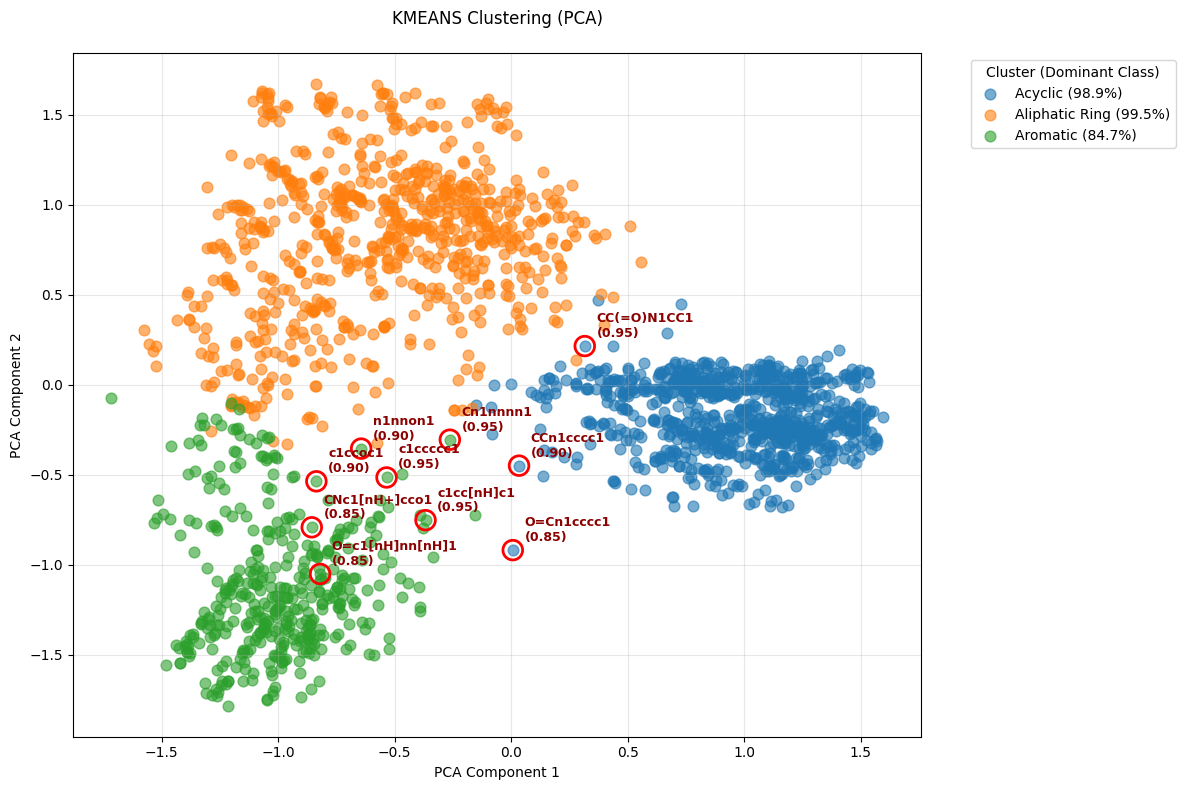

In [8]:
true_labels = qm9.df['structure_class']
num_clusters = len(set(true_labels))

X = np.array(qm9.df["morgan_fingerprint"].to_list(), dtype=np.float32)
analyzer = ClusterAnalysis(X, true_labels=true_labels, meta_df=qm9.df) 
kmeans_labels = analyzer.run(method='kmeans', n_clusters=num_clusters)
analyzer.plot_pca(highlight_top_overlaps=10, use_pca=False)